<a href="https://colab.research.google.com/github/thrower19/all_target_model_data/blob/main/16_afids_trained_GT_afids_RN_pred.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
### IMPORTS ###
import pickle
from glob import glob
import pandas as pd
import numpy as np
from google.colab import drive
import os
import seaborn as sns
import re
from itertools import cycle
from plotly.offline import plot
import plotly.graph_objs as go
import matplotlib.cm as cm
import random as rand
import nibabel as nib
import base64
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from io import BytesIO
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import RidgeCV,Ridge
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import ElasticNetCV
from sklearn.linear_model import MultiTaskElasticNetCV
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from itertools import cycle

In [2]:
!pip install --force-reinstall numpy==1.26.4

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 40.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... canceled
ERROR: Operation cancelled by user


In [3]:
### Variables ###
%config InlineBackend.figure_format = 'retina' #to make plots look sharper
ANALYSIS = 'RN'

In [4]:
### HELPER FUNCTIONS ###
afids_labels = {
    1: 'AC', 2: 'PC', 3: 'ICS', 4: 'PMJ', 5: 'SIPF', 6: 'RSLMS',
    7: 'LSLMS', 8: 'RILMS', 9: 'LILMS', 10: 'CUL', 11: 'IMS', 12: 'RMB',
    13: 'LMB', 14: 'PG', 15: 'RLVAC', 16: 'LLVAC', 17: 'RLVPC', 18: 'LLVPC',
    19: 'GENU', 20: 'SPLE', 21: 'RALTH', 22: 'LALTH', 23: 'RSAMTH',
    24: 'LSAMTH', 25: 'RIAMTH', 26: 'LIAMTH', 27: 'RIGO', 28: 'LIGO',
    29: 'RVOH', 30: 'LVOH', 31: 'ROSF', 32: 'LOSF'
}

#hardcoding right and left hemisphere afids
right_afids = ['x_6','x_8','x_12','x_15','x_17','x_21','x_23','x_25','x_27','x_29','x_31','y_6','y_8','y_12','y_15','y_17','y_21','y_23','y_25','y_27','y_29','y_31', 'z_6','z_8','z_12','z_15','z_17','z_21','z_23','z_25','z_27','z_29','z_31']
left_afids = ['x_7','x_9','x_13','x_16','x_18','x_22','x_24','x_26','x_28','x_30','x_32','y_7','y_9','y_13','y_16','y_18','y_22','y_24','y_26','y_28','y_30','y_32', 'z_7','z_9','z_13','z_16','z_18','z_22','z_24','z_26','z_28','z_30','z_32']
combined_lables = ['AC','PC', 'ICS', 'PMJ','SIPF','SLMS','ILMS','CUL','IMS','MB','PG','LVAC','LVPC','GENU','SPLE','ALTH','SAMTH','IAMTH','IGO','VOH','OSF']
combined_lables = [element + axis for axis in ['x', 'y', 'z'] for element in combined_lables]
r = [6,8,12,15,17,21,23,25,27,29,31]
l = [7,9,13,16,18,22,24,26,28,30,32]

exclude_afids_labels = [10,14,19,20,21,22,23,24,25,26,27,28,29,30,31,32]
#exclude_afids_labels = []
# Used for filtering AFIDs
exclude_afids = ['CULx','PGx','GENUx', 'SPLEx', 'ALTHx', 'SAMTHx', 'IAMTHx', 'IGOx','VOHx','OSFx',
                 'CULy','PGy','GENUy', 'SPLEy', 'ALTHy', 'SAMTHy', 'IAMTHy', 'IGOy','VOHy','OSFy',
                 'CULz','PGz','GENUz', 'SPLEz', 'ALTHz', 'SAMTHz', 'IAMTHz', 'IGOz','VOHz','OSFz'
                ]
#exclude_afids = []

def fcsvtodf(fcsv_path):
    """
    Convert a .fcsv file (assumes RAS coordinate system) to a ML-friendly dataframe and return the cleaned xyz coordinates.

    Parameters:
    - fcsv_path: str, path to the .fcsv file

    Returns:
    - df_xyz_clean: pandas.DataFrame with cleaned x, y, z coordinates
    - num_points: int, number of fiducial points
    """

    # Extract the subject ID from the file path (naming is in bids-like)
    subject_id = re.search(r'(sub-\w+)', fcsv_path).group(1)

    # Read in .fcsv file, skip header
    df_raw = pd.read_table(fcsv_path,sep=',',header=2)

    #Extract the x, y, z coordiantes and store them in data science friendly format (i.e., features in cols and subject in rows)
    df_xyz = df_raw[['x','y','z']].melt().transpose()

    #Use number of row in fcsv to make number points
    colnames = [f'{axis}_{i % int(df_raw.shape[0]) + 1}' for axis in ['x', 'y', 'z'] for i in range(int(df_raw.shape[0]))]

    #Reassign features to be descriptive of coordinate
    df_xyz.columns = colnames

    #clean dataframe and pin correct subject name
    df_xyz_clean = df_xyz.drop('variable', axis= 0)
    df_xyz_clean = df_xyz_clean.rename(index={'value': subject_id})
    df_xyz_clean = df_xyz_clean.astype(float)

    return df_xyz_clean, df_raw.shape[0]


def get_fiducial_index(fid):
    """
    Retrieve the index corresponding to the fiducial name or integer.

    Parameters:
    - fid: str or int, fiducial identifier (name or index)

    Returns:
    - int, corresponding fiducial index
    """

    if isinstance(fid, str):
        for idx, name in afids_labels.items():
            if name == fid:
                return idx
    elif isinstance(fid, int):
        return fid
    raise ValueError("Invalid fiducial identifier.")


def compute_distance(fcsv_path, fid1, fid2):
    """
    Compute the Euclidean distance between two fiducials.

    Parameters:
    - fcsv_path: str, path to the .fcsv file
    - fid1, fid2: str or int, fiducial identifiers

    Returns:
    - xyz_diff: numpy.array, difference in x, y, z coordinates
    - distance: float, Euclidean distance between fiducials
    """

    # Retrieve indices of the fiducials
    index1, index2 = get_fiducial_index(fid1), get_fiducial_index(fid2)

    # Load dataframe from the fcsv file
    df = fcsvtodf(fcsv_path)[0]

    # Extract x, y, z coordinates into numpy arrays
    coords1 = df[[f'x_{index1}', f'y_{index1}', f'z_{index1}']].to_numpy()
    coords2 = df[[f'x_{index2}', f'y_{index2}', f'z_{index2}']].to_numpy()

    # Compute the difference as a numpy array
    xyz_diff = coords1 - coords2

    # Compute the Euclidean distance
    distance = np.linalg.norm(xyz_diff)

    return xyz_diff.flatten(), distance


def compute_average(fcsv_path, fid1, fid2):
    """
    Compute the average position between two fiducials.

    Parameters:
    - fcsv_path: str, path to the .fcsv file
    - fid1, fid2: str or int, fiducial identifiers

    Returns:
    - xyz_average: numpy.array, average coordinates (x, y, z) between fiducials
    """

    # Retrieve indices of the fiducials
    index1, index2 = get_fiducial_index(fid1), get_fiducial_index(fid2)

    # Load dataframe from the fcsv file
    df = fcsvtodf(fcsv_path)[0]

    # Extract x, y, z coordinates into numpy arrays
    coords1 = df[[f'x_{index1}', f'y_{index1}', f'z_{index1}']].to_numpy()
    coords2 = df[[f'x_{index2}', f'y_{index2}', f'z_{index2}']].to_numpy()

    # Compute the average as a numpy array
    xyz_average = (coords1 + coords2)/2

    return xyz_average.flatten()


def acpcmatrix(fcsv_path, midline, center_on_mcp = True, write_matrix = False, transform_file_name = None):
    """
    Computes a 4x4 transformation matrix aligning with the AC-PC axis.

    Parameters:
    - fcsv_path: str, path to the .fcsv file
    - midline: str or int, one of the 10 midline AFID points.
    - center_on_mcp: bool, If True, adds translation element to the ACPC matrix (centering on MCP).

    Returns:
    - matrix: np.ndarray, A 4x4 affine transformation matrix.
    """

    # A-P axis
    acpc = compute_distance(fcsv_path, 'AC', 'PC')  # vector from PC to AC
    yAxis = acpc[0] / acpc[1]  # unit vector defining anterior and posterior axis

    # R-L axis
    lataxis = compute_distance(fcsv_path, midline, 'AC')[0] # vector from AC to midline point
    xAxis = np.cross(yAxis, lataxis) # vector defining left and right axis
    xAxis /= np.linalg.norm(xAxis) # unit vector defining left and right axis

    # S-I axis
    zAxis = np.cross(xAxis, yAxis)
    zAxis /= np.linalg.norm(zAxis)

    # Rotation matrix
    rotation = np.vstack([xAxis, yAxis, zAxis])
    translation = np.array([0, 0, 0])

    # Build 4x4 matrix
    matrix = np.eye(4)
    matrix[:3, :3] = rotation
    matrix[:3, 3] = translation

    # Orientation correction for matrix is midpoint placed below ACPC (i.e., at PMJ)
    if matrix[0][0] < 0:
        matrix = matrix * np.array([[-1,-1,-1,0],
                                    [1,1,1,0],
                                    [-1,-1,-1,0],
                                    [0,0,0,1]])

    if center_on_mcp: #need to compute MCP AFTER rotation is applied
        mcp = compute_average(fcsv_path,'AC','PC') #MCP in native
        matrix[:3, 3] = -np.dot(matrix[:3, :3], mcp) # MCP after rotation; negative because we set MCP to (0,0,0)

    if write_matrix:
        generate_slicer_file(matrix, transform_file_name)

    return matrix

def extract_sub_metadata(fcsv_path):
    """
    Extracts subject id, description, and dataset following bids-like structure.

    Parameters:
    - fcsv_path: str, path to the .fcsv file

    Returns:
    - sub_id: str, subject ID
    - description: str, description label
    - dataset: str, dataset
    """

    filename = os.path.basename(fcsv_path)

    sub_id_match = re.search(r'^sub-[A-Za-z0-9]+', filename)
    sub_id = sub_id_match.group() if sub_id_match else 'unknown'

    description_match = re.search(r'desc-([A-Za-z0-9\-]+)', filename)
    description = description_match.group(1) if description_match else 'unknown'

    parts = fcsv_path.split(os.sep)

    dataset = "unknown_dataset"

    for i, part in enumerate(parts):
        if part == 'anat':
            if i >= 3:
                dataset = parts[i - 3]
            break  # exit after finding the first match


    match = re.search(r'_([a-zA-Z0-9]+)\.fcsv', parts[-1])
    if match:
        coord_type = match.group(1)
    else:
        coord_type = "unknown_coordinatetype"

    return sub_id, description, dataset, coord_type



def transform_afids(fcsv_path, midline_fcsv=None, output_dir=None, midpoint='PMJ', save_matrix = False):
    """
    Computes and applies an AC-PC transformation to AFID files and saves an fcsv with transfromed coordinates.

    Parameters:
    - fcsv_path: str, path to the .fcsv file for coordinates to be transformed
    - midline_fcsv: str, path to the .fcsv file which has the midline coordinates
    - output_dir: str, path of the directory to store transformed .fcsv file (if not specified, no output fcsv will be written)
    - midpoint: str or int, any midline AFID point

    Returns:
    - tcoords: np.ndarray, transformed coordinates
    """
    if midline_fcsv:
        # Compute the 4x4 AC-PC transformation matrix
        xfm_txt = acpcmatrix(midline_fcsv, midpoint)
    else:
        xfm_txt = acpcmatrix(fcsv_path, midpoint)

    # Read header lines separately
    with open(fcsv_path, 'r') as file:
        header_lines = [next(file) for _ in range(3)]

    # Read coordinates from the file
    fcsv_df = pd.read_table(fcsv_path, sep=",", header=2)

    # Copy coordinates and apply transformation
    pretfm = fcsv_df.loc[:, ["x", "y", "z"]].copy()
    pretfm["coord"] = 1  # Add a fourth column for homogeneous coordinates
    coords = pretfm.to_numpy()
    thcoords = xfm_txt @ coords.T
    tcoords = thcoords.T[:, :3]  # Remove homogeneous coordinates

    # Substitute new coordinates
    if tcoords.shape == (len(fcsv_df), 3):
        fcsv_df.loc[:, "x"] = tcoords[:, 0]
        fcsv_df.loc[:, "y"] = tcoords[:, 1]
        fcsv_df.loc[:, "z"] = tcoords[:, 2]
    else:
        raise ValueError("New coordinates do not match the number of rows in the original fcsv.")

    if output_dir is not None:
        # Save the transformed coordinates to a new fcsv file
        sub_desc_dataset = extract_sub_metadata(fcsv_path)
        output_filename = f'{sub_desc_dataset[0]}_space-MCP{midpoint}_desc-{sub_desc_dataset[1]}_{sub_desc_dataset[3]}.fcsv'
        output_bids = f"{sub_desc_dataset[2]}/{sub_desc_dataset[3]}_mcp/{sub_desc_dataset[0]}/anat"
        full_out_dir = os.path.join(output_dir, output_bids)
        if not os.path.exists(full_out_dir):
            os.makedirs(full_out_dir)

        output_path = os.path.join(full_out_dir, output_filename)

        # Write the header and updated DataFrame to the new fcsv file with specific formatting
        with open(output_path, 'w') as file:
            file.writelines(header_lines)
            fcsv_df.to_csv(file, sep=",", index=False, header=False, float_format="%.5f")
        if save_matrix:
            # Reconstruct path with approriate extension
            tfm_path = os.path.splitext(output_path)[0] + '.txt'
            generate_slicer_file(xfm_txt,tfm_path)

        print(f"Saved transformed file: {output_filename}")

    return tcoords


def coords_to_fcsv(coords, fcsv_template, fcsv_output):
    """
    Updates an fcsv template file with new coordinates and writes the updated version to a new file.
    Ensures the directory for the output file exists before writing.

    Parameters:
    - coords: ndarray, array of shape (n, 3) containing the coordinates for each fiducial.
    - fcsv_template: str, path to a template fcsv file that can be used as a reference.
    - fcsv_output: str, path where the output fcsv file with updated coordinates will be written.
    """

    # Ensure output directory exists
    output_dir = os.path.dirname(fcsv_output)
    os.makedirs(output_dir, exist_ok=True)

    # Read in the fcsv template
    with open(fcsv_template, "r") as f:
        fcsv = [line.strip() for line in f]

    # Loop over each fiducial in the coordinates
    for fid in range(1, coords.shape[0] + 1):
        # Update fcsv, skipping header lines (first 3 lines assumed to be header)
        line_idx = fid + 2  # Line to update with new coordinates
        centroid_idx = fid - 1  # Index of the current point in coords

        # Replace the placeholders for x, y, and z coordinates
        fcsv[line_idx] = fcsv[line_idx].replace(
            f"afid{fid}_x", str(coords[centroid_idx][0])
        ).replace(
            f"afid{fid}_y", str(coords[centroid_idx][1])
        ).replace(
            f"afid{fid}_z", str(coords[centroid_idx][2])
        )

    # Write the updated fcsv to the output file
    with open(fcsv_output, "w") as f:
        f.write("\n".join(fcsv))



def generate_slicer_file(matrix, filename):
    """
    Generate a .txt transformation file for 3D Slicer from a 4x4 matrix.

    Parameters:
    - matrix: np.ndarray, 4x4 transformation matrix
    - output_path: str, path to store .txt file
    """
    D = np.array([
    [-1,  0,  0, 0],
    [ 0, -1,  0, 0],
    [ 0,  0,  1, 0],
    [ 0,  0,  0, 1]
    ])

    ras_inmatrix = np.linalg.inv(matrix)

    lps_inmatrix = D @ ras_inmatrix @ D

    # Extract rotation/scale and translation components
    rotation_scale = lps_inmatrix[0:3, 0:3].flatten()
    translation = lps_inmatrix[0:3, 3]

    # Format the content of the .tfm file
    tfm_content = "#Insight Transform File V1.0\n"
    tfm_content += "#Transform 0\n"
    tfm_content += "Transform: AffineTransform_double_3_3\n"
    tfm_content += "Parameters: " + " ".join(map(str, rotation_scale)) + " " + " ".join(map(str, translation)) + "\n"
    tfm_content += "FixedParameters: 0 0 0\n"

    # Write the content to the specified file
    with open(filename, 'w') as file:
        file.write(tfm_content)

    print(f"{filename} has been generated.")

def save_single_slice_in_memory(data, x, y, z, offset, zoom_radius, show_crosshairs):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    for i, (slice_data, coord, title) in enumerate(
        zip(
            [data[x + offset, :, :], data[:, y + offset, :], data[:, :, z + offset]],
            [(y, z), (x, z), (x, y)],
            ["Sagittal", "Coronal", "Axial"],
        )
    ):
        axes[i].imshow(slice_data.T, origin='lower', cmap='gray')
        if offset == 0 and show_crosshairs:
            axes[i].axhline(y=coord[1], color='r', lw=1)
            axes[i].axvline(x=coord[0], color='r', lw=1)
        axes[i].set_xlim(coord[0] - zoom_radius, coord[0] + zoom_radius)
        axes[i].set_ylim(coord[1] - zoom_radius, coord[1] + zoom_radius)
        axes[i].set_title(title)
        axes[i].axis('off')

    buffer = BytesIO()
    plt.savefig(buffer, format='png', bbox_inches='tight')
    plt.close(fig)
    buffer.seek(0)

    return base64.b64encode(buffer.read()).decode()

def save_mri_slices_as_images(data, x, y, z, jitter, zoom_radius, show_crosshairs=True):
    return Parallel(n_jobs=-1)(
        delayed(save_single_slice_in_memory)(data, x, y, z, offset, zoom_radius, show_crosshairs)
        for offset in range(-jitter, jitter + 1)
    )

def extract_coordinates_from_fcsv(file_path, label_description):
    df = pd.read_csv(file_path, comment='#', header=None)
    row = df[df[11] == label_description]
    return tuple(row.iloc[0, 1:4]) if not row.empty else None

def generate_html_with_keypress(subject_images, reference_images, output_html="mri_viewer.html"):
    """Generate an interactive HTML viewer with sticky instructions."""
    html_content = """
    <!DOCTYPE html>
    <html lang="en">
    <head>
        <meta charset="UTF-8">
        <meta name="viewport" content="width=device-width, initial-scale=1.0">
        <title>MRI Viewer</title>
        <style>
            body { display: flex; font-family: Arial, sans-serif; margin: 0; padding: 0; }
            .instructions {
                width: 20%; padding: 20px; background-color: #f4f4f4;
                border-right: 2px solid #ddd;
                position: sticky; top: 0; height: 100vh; overflow-y: auto;
                box-sizing: border-box;
            }
            .instructions h2 { margin-top: 0; }
            .viewer { flex: 1; padding: 20px; text-align: center; }
            .slider { width: 80%; margin: 20px auto; }
            .image { display: block; margin: 0 auto; max-width: 80%; transition: opacity 0.2s ease-in-out; }
        </style>
    </head>
    <body>
        <div class="instructions">
            <h2>Tips & Tricks</h2>
            <ul>
                <li>Use the <strong>slider</strong> to navigate through MRI. Keyboard can also be used after clicking on slider.</li>
                <li>Check the <strong>Red</strong> crosshair which represents the placement of a given landmark.</li>
                <li>Press <strong>R</strong> to toggle between the subject scan and the protocol-defined placement (if one exists).</li>
                <li>Use the <strong>TAB</strong> key to navigate to next slider & MRI.</li>
            </ul>
        </div>
        <div class="viewer">
    """

    for label, images in subject_images.items():
        num_slices = len(images)
        has_reference = reference_images is not None and label in reference_images

        html_content += f"""
        <div class="container">
            <h2>Landmark: {label}</h2>
            <img id="{label}_image" class="image" src="data:image/png;base64,{images[0]}" alt="MRI Slice">
            <input type="range" min="0" max="{num_slices - 1}" value="0" class="slider" id="{label}_slider">
        </div>
        """

    html_content += """
        </div>
        <script>
            const subjects = {};
    """

    for label, images in subject_images.items():
        has_reference = reference_images is not None and label in reference_images
        html_content += f"""
            subjects["{label}"] = {{
                targetImages: {images},
                referenceImages: {reference_images[label] if has_reference else "null"},
                showingReference: false
            }};
        """

    html_content += """
            document.addEventListener('DOMContentLoaded', () => {
                for (const [label, data] of Object.entries(subjects)) {
                    const slider = document.getElementById(`${label}_slider`);
                    const image = document.getElementById(`${label}_image`);

                    slider.addEventListener('input', () => updateImage(label));
                    document.addEventListener('keydown', (event) => {
                        if (event.key.toLowerCase() === 'r' && data.referenceImages) {
                            data.showingReference = !data.showingReference;
                            updateImage(label);
                        }
                    });

                    function updateImage(label) {
                        const sliceIndex = document.getElementById(`${label}_slider`).value;
                        const imageArray = subjects[label].showingReference
                            ? subjects[label].referenceImages
                            : subjects[label].targetImages;
                        document.getElementById(`${label}_image`).src = 'data:image/png;base64,' + imageArray[sliceIndex];
                    }
                }
            });
        </script>
    </body>
    </html>
    """

    with open(output_html, "w") as f:
        f.write(html_content)

def generate_interactive_mri_html(nii_path, fcsv_path, labels, ref_nii_path=None, ref_fcsv_path=None, jitter=2, zoom_radius=20, out_file_prefix="mri_viewer"):
    """
    Generates an interactive HTML viewer for MRI slices based on fiducial coordinates for a single subject.

    Parameters:
    - nii_path: str
        Full path to the subject's NIfTI (.nii.gz) file.
    - fcsv_path: str
        Full path to the subject's FCSV (.fcsv) file.
    - labels: list of int
        Landmark indices to extract for the subject.
    - ref_nii_path: str or None
        Full path to reference NIfTI file (optional).
    - ref_fcsv_path: str or None
        Full path to reference FCSV file (optional).
    - jitter: int, optional (default=2)
        The number of pixels to expand around the coordinate in each slice for visualization.
    - zoom_radius: int, optional (default=20)
        The radius (in pixels) around the coordinate to extract for display.
    - out_file_prefix: str, optional (default="mri_viewer")
        The prefix for the output HTML file name.

    Notes:
    - Extracts specified fiducial coordinates from the subject's .fcsv file.
    - Maps the coordinates from world space to voxel space using the NIfTI affine transformation.
    - MRI slices centered around these coordinates are saved as images.
    - If a reference MRI and coordinate file are provided, the same process is applied.
    - Generates an interactive HTML viewer allowing keypress navigation.

    Returns:
    - None (outputs an HTML file with the interactive MRI viewer for the subject).
    """
    subject_key = os.path.basename(nii_path).replace(".nii.gz", "")
    target_img = nib.load(nii_path, mmap=True)
    affine_inv = np.linalg.inv(target_img.affine)
    target_data = target_img.get_fdata(dtype=np.float32)

    target_images = {}  # Dictionary to store images per landmark

    for label in labels:
        target_coord = extract_coordinates_from_fcsv(fcsv_path, label)
        if not target_coord:
            print(f"Coordinates for label '{label}' not found in subject '{subject_key}'.")
            continue

        target_voxel = np.round(affine_inv.dot(target_coord + (1,))).astype(int)
        target_images[label] = save_mri_slices_as_images(target_data, *target_voxel[:3], jitter, zoom_radius)

    reference_images = None
    if ref_nii_path and ref_fcsv_path:
        ref_img = nib.load(ref_nii_path, mmap=True)
        ref_data = ref_img.get_fdata(dtype=np.float32)
        reference_images = {}

        for label in labels:
            ref_coord = extract_coordinates_from_fcsv(ref_fcsv_path, label)
            if ref_coord:
                ref_voxel = np.round(np.linalg.inv(ref_img.affine).dot(ref_coord + (1,))).astype(int)
                reference_images[label] = save_mri_slices_as_images(ref_data, *ref_voxel[:3], jitter, zoom_radius)
    os.makedirs(out_file_prefix, exist_ok=True)

    out_file = f"{out_file_prefix}{subject_key}.html"

    print(f"Generated: {out_file}")

    # Pass the correct image dictionaries
    generate_html_with_keypress(target_images, reference_images, out_file)

def flip_and_concatenate_hemispheres(df_afids):
    """
    Flips hemispheres by removing left/right AFIDs, relabels columns, and concatenates
    mirrored and non-mirrored data.

    Parameters:
        df_afids (pd.DataFrame): Original DataFrame of AFID coordinates.
        afidutils (module or object): Utility with attributes:
            - left_afids (list): Column names for left hemisphere AFIDs.
            - right_afids (list): Column names for right hemisphere AFIDs.
            - combined_lables (list): Unified column names after hemisphere flip.
            - exclude_afids (list): Columns to exclude from final DataFrame.

    Returns:
        pd.DataFrame: Combined and cleaned DataFrame with flipped hemispheres.
    """
    df_afids_mcp_l = df_afids.copy()
    df_afids_mcp_l[[col for col in df_afids.columns if 'x' in col]] *= -1

    # Drop left hemisphere from one copy, right from the other
    df_afids_mcp = df_afids.drop(left_afids, axis=1)
    df_afids_mcp_l = df_afids_mcp_l.drop(right_afids, axis=1)

    # Rename columns to have consistent structure
    df_afids_mcp.columns = combined_lables
    df_afids_mcp_l.columns = combined_lables

    # Concatenate mirrored and original data
    concatenated_df = pd.concat([df_afids_mcp, df_afids_mcp_l])

    return concatenated_df


def predict_RN_coordinates(
    subject_afid_path,
    model_path
):
    """
    Runs the trained AFIDs -> RN model on a single subject and returns predicted coordinates.

    Parameters
    ----------
    subject_afid_path : str
        Path to the subject's .fcsv AFID file in ACPC + mcp centered space.
    model_path : str
        Path to the trained model pickle file.
    afidutils : module
        AFID utility module, must include:
        - fcsvtodf()
        - left_afids, right_afids, combined_lables, exclude_afids

    Returns
    -------
    y_pred : np.ndarray
        Predicted RN coordinates, shape (82, 3).
    """

    # Load subject AFIDs
    df = fcsvtodf(subject_afid_path)[0]

    # values between -0.01 and 0.01 are set to zero
    df.map(make_zero)

    df_proc = flip_and_concatenate_hemispheres(df)

    # Load model
    with open(model_path, 'rb') as file:
        model_dict = pickle.load(file)

    scaler = model_dict['standard_scaler']
    pca = model_dict['pca']
    ridge_models = [model_dict['x'], model_dict['y'], model_dict['z']]

    # Transform
    X = scaler.transform(df_proc.values)
    X = pca.transform(X)

    # Predict RN
    y_pred = np.column_stack([ridge.predict(X) for ridge in ridge_models])

    return y_pred

def make_zero(num, threshold=0.01):
    if abs(num) < threshold:
        return 0
    else:
        return num

def remove_outliers(df, cols, threshold=3.5):
    """
    Remove rows from a DataFrame based on a modified Z-score for a given column(s).
    """
    for col in cols:
        median = np.median(df[col])
        mad = np.median(np.abs(df[col] - median))
        if mad == 0:
            mad = 1.0
        z_scores = 0.6745 * (df[col] - median) / mad
        df = df.loc[abs(z_scores) < threshold]
    return df

def create_list(n):
    numbers = list(range(1, n + 1))  # Create a list of numbers from 1 to n
    repeated_numbers = cycle(numbers)  # Create a cycle iterator for the numbers
    result = [next(repeated_numbers) for _ in range(n * 2)]  # Generate n*2 elements by cycling through the numbers
    return result

def determineFCSVCoordSystem(input_fcsv, overwrite_fcsv=False):
    # need to determine if file is in RAS or LPS
    # loop through header to find coordinate system
    coordFlag = re.compile("# CoordinateSystem")
    verFlag = re.compile("# Markups fiducial file version")
    headFlag = re.compile("# columns")
    coord_sys = None
    headFin = None
    ver_fin = None

    with open(input_fcsv, "r") as myfile:
        firstNlines = myfile.readlines()[0:3]

    for row in firstNlines:
        row = re.sub("[\s\,]+[\,]", "", row).replace("\n", "")
        cleaned_dict = {row.split("=")[0].strip(): row.split("=")[1].strip()}
        if None in list(cleaned_dict):
            cleaned_dict["# columns"] = cleaned_dict.pop(None)
        if any(coordFlag.match(x) for x in list(cleaned_dict)):
            coord_sys = list(cleaned_dict.values())[0]
        if any(verFlag.match(x) for x in list(cleaned_dict)):
            verString = list(filter(verFlag.match, list(cleaned_dict)))
            assert len(verString) == 1
            ver_fin = verString[0].split("=")[-1].strip()
        if any(headFlag.match(x) for x in list(cleaned_dict)):
            headFin = list(cleaned_dict.values())[0].split(",")

    if any(x in coord_sys for x in {"LPS", "1"}):
        df = pd.read_csv(input_fcsv, skiprows=3, header=None)

        if df.shape[1] != 13:
            df = df.iloc[:, :14]

        df[1] = -1 * df[1]  # flip orientation in x
        df[2] = -1 * df[2]  # flip orientation in y

        if overwrite_fcsv:
            with open(input_fcsv, "w") as fid:
                fid.write("# Markups fiducial file version = 4.11\n")
                fid.write("# CoordinateSystem = 0\n")
                fid.write(
                    "# columns = id,x,y,z,ow,ox,oy,oz,vis,sel,lock,label,desc,associatedNodeID\n"
                )

            df.rename(
                columns={
                    0: "node_id",
                    1: "x",
                    2: "y",
                    3: "z",
                    4: "ow",
                    5: "ox",
                    6: "oy",
                    7: "oz",
                    8: "vis",
                    9: "sel",
                    10: "lock",
                    11: "label",
                    12: "description",
                    13: "associatedNodeID",
                },
                inplace=True,
            )

            df["associatedNodeID"] = pd.Series(np.repeat("", df.shape[0]))
            df.round(6).to_csv(
                input_fcsv,
                sep=",",
                index=False,
                lineterminator="",
                mode="a",
                header=False,
                float_format="%.6f",
            )

            # print(
            #     f"Converted LPS to RAS: {os.path.dirname(input_fcsv)}/{os.path.basename(input_fcsv)}"
            # )
    return coord_sys, headFin

<>:699: SyntaxWarning:

invalid escape sequence '\s'

<>:699: SyntaxWarning:

invalid escape sequence '\s'

/tmp/ipykernel_624/2827450517.py:699: SyntaxWarning:

invalid escape sequence '\s'



In [5]:
# Step 1: Remove the existing cloned directory
!rm -rf /content/all_target_model_data
print("Existing 'target_project_data' directory removed.")

Existing 'target_project_data' directory removed.


In [6]:
!git clone https://github.com/thrower19/all_target_model_data.git #Clone coordinate data

Cloning into 'all_target_model_data'...
remote: Enumerating objects: 222, done.
remote: Counting objects: 100% (222/222), done.
remote: Compressing objects: 100% (63/63), done.
remote: Total 222 (delta 133), reused 205 (delta 125), pack-reused 0 (from 0)
Receiving objects: 100% (222/222), 3.58 MiB | 17.79 MiB/s, done.
Resolving deltas: 100% (133/133), done.


In [7]:
#load AFID coordiante data
afid_fcsv = sorted(glob(f'/content/all_target_model_data/training_data/training_features/afids_groundtruth/sub-*/anat/sub-*_acq-MP2RAGE_run-01_space-T1w_desc-groundtruth_afids.fcsv'))
print(f'number of 7T subjects with AFID annotations: {len(afid_fcsv)}')

#load RN coordiante data
DBS_fcsv = sorted(glob(f"/content/all_target_model_data/training_data/training_targets/RN_GT_centroids/sub-*_RN_contacts.fcsv"))
print(f'number of subjects with {ANALYSIS} annotations: {len(DBS_fcsv)}')

number of 7T subjects with AFID annotations: 32
number of subjects with RN annotations: 32


In [8]:
# Path to AFIDs ground truth directory for the current dataset
dirafids = f"/content/all_target_model_data/training_data/training_features/afids_groundtruth"

# Get a sorted list of subject IDs (folders that start with "sub-")
SUBJIDs = sorted([name for name in os.listdir(dirafids) if name.startswith("sub-")])
print(SUBJIDs)

# Loop through each subject
for subjid in SUBJIDs:
    print(subjid)

    # Find the subject's AFID (*.fcsv) file
    fid_fcsv = sorted(glob(f"/content/all_target_model_data/training_data/training_features/afids_groundtruth/{subjid}/anat/sub-*_acq-MP2RAGE_run-01_space-T1w_desc-groundtruth_afids.fcsv"))[0]

    # Determine and convert AFID FCSV coordinate system if needed
    determineFCSVCoordSystem(fid_fcsv, overwrite_fcsv=True)

    # Apply AC-PC transform and MCP centering to AFIDs
    transform_afids(
        fid_fcsv,
        output_dir=f'{dirafids}/ACPC', # bids-like outputs (fcsv file + transformation matrix)
        save_matrix=True #saves transformation matrix
    )

    # Find the subject's ZI (*.fcsv) file
    subRN_fcsv = sorted(glob(f"/content/all_target_model_data/training_data/training_targets/RN_GT_centroids/{subjid}_RN_contacts.fcsv"))[0]

    # Determine and convert RN FCSV coordinate system if needed
    determineFCSVCoordSystem(subRN_fcsv, overwrite_fcsv=True)

    # Apply AC-PC + MCP transform to RN file using AFID file as reference
    transform_afids(
        subRN_fcsv,
        fid_fcsv, #need the AFID file to compute ACPC matrix
        output_dir=f'{dirafids}/ACPC', # bids-like outputs (fcsv file + transformation matrix)
        save_matrix=True #saves transformation matrix
    )

['sub-C001', 'sub-C002', 'sub-C003', 'sub-C004', 'sub-C005', 'sub-C006', 'sub-C007', 'sub-C008', 'sub-C009', 'sub-C010', 'sub-C011', 'sub-C012', 'sub-C013', 'sub-C015', 'sub-C016', 'sub-C018', 'sub-C019', 'sub-C020', 'sub-C021', 'sub-C022', 'sub-C023', 'sub-C024', 'sub-C025', 'sub-C026', 'sub-C027', 'sub-C028', 'sub-C029', 'sub-C030', 'sub-C031', 'sub-C032', 'sub-C033', 'sub-C034']
sub-C001
/content/all_target_model_data/training_data/training_features/afids_groundtruth/ACPC/training_features/afids_mcp/sub-C001/anat/sub-C001_space-MCPPMJ_desc-groundtruth_afids.txt has been generated.
Saved transformed file: sub-C001_space-MCPPMJ_desc-groundtruth_afids.fcsv
/content/all_target_model_data/training_data/training_features/afids_groundtruth/ACPC/unknown_dataset/contacts_mcp/sub-C001/anat/sub-C001_space-MCPPMJ_desc-unknown_contacts.txt has been generated.
Saved transformed file: sub-C001_space-MCPPMJ_desc-unknown_contacts.fcsv
sub-C002
/content/all_target_model_data/training_data/training_fe

In [9]:
# Paths
base_path = f'/content/all_target_model_data/training_data/training_features/afids_groundtruth'
RN_path = f'{base_path}/ACPC/unknown_dataset/contacts_mcp'
afids_path = f'{base_path}/ACPC/training_features/afids_mcp'

# Get list of RN coordinate files (MCP-aligned)
RN_fcsv = sorted(glob(f'{RN_path}/sub-*/anat/sub-*_space-MCPPMJ*.fcsv'))

# Load and concatenate RN data
df_RN = pd.concat([fcsvtodf(s)[0] for s in RN_fcsv], axis=0)
df_RN.columns = ['RTargetx', 'LTargetx', 'RTargety', 'LTargety', 'RTargetz', 'LTargetz']

# Mirror left RN x-coordinates
df_RN['LTargetx'] *= -1

# Create left/right RN DataFrames with common labels
df_RN_r = df_RN[['RTargetx', 'RTargety', 'RTargetz']].rename(columns=lambda c: c[1:])
df_RN_l = df_RN[['LTargetx', 'LTargety', 'LTargetz']].rename(columns=lambda c: c[1:])
df_RN_proc = pd.concat([df_RN_r, df_RN_l], axis=0)

# Load subject-level AFIDs and concatenate
afids_fcsv = sorted(glob(f'{afids_path}/sub-*/anat/sub-*_space-MCPPMJ*.fcsv'))

df_subs_afids = pd.concat([fcsvtodf(f)[0] for f in afids_fcsv], axis=0)

df_afids_proc = flip_and_concatenate_hemispheres(df_subs_afids)

df_afids_proc_exclusions = df_afids_proc.drop(columns=exclude_afids)

drop_for_now = ['sub-C008'] #EXCLUDED because MISSING right GT expert annotation

df_afids_proc_exclusions = df_afids_proc_exclusions.drop(drop_for_now)
df_RN_proc = df_RN_proc.drop(drop_for_now)

# Select training data
df_afids_proc_train = df_afids_proc_exclusions
df_RN_proc_train = df_RN_proc

# Create np. arrays
df_afids_proc_train = df_afids_proc_train.to_numpy()
df_RN_proc_train = df_RN_proc_train.to_numpy()

In [10]:
df_afids_proc_exclusions.columns

Index(['ACx', 'PCx', 'ICSx', 'PMJx', 'SIPFx', 'SLMSx', 'ILMSx', 'IMSx', 'MBx',
       'LVACx', 'LVPCx', 'ACy', 'PCy', 'ICSy', 'PMJy', 'SIPFy', 'SLMSy',
       'ILMSy', 'IMSy', 'MBy', 'LVACy', 'LVPCy', 'ACz', 'PCz', 'ICSz', 'PMJz',
       'SIPFz', 'SLMSz', 'ILMSz', 'IMSz', 'MBz', 'LVACz', 'LVPCz'],
      dtype='object')

In [11]:
df_afids_proc_exclusions

,ACx,PCx,ICSx,PMJx,SIPFx,SLMSx,ILMSx,IMSx,MBx,LVACx,...,PCz,ICSz,PMJz,SIPFz,SLMSz,ILMSz,IMSz,MBz,LVACz,LVPCz
sub-C001,-0.0,0.0,0.09183,0.0,0.06511,12.24723,9.95165,0.10809,1.96318,16.54652,...,0.0,-7.63595,-18.12624,-5.89543,-6.15574,-15.97340,-8.39205,-8.05452,24.65166,23.97373
sub-C002,0.0,0.0,-0.08451,-0.0,-0.06349,11.23464,10.32108,-0.19655,1.72792,14.80512,...,-0.0,-7.43879,-16.62802,-6.78201,-5.93488,-17.52200,-9.44738,-9.52985,25.53416,24.79121
sub-C003,0.0,0.0,0.22036,0.0,-0.27026,11.80386,9.84867,-0.33037,2.17192,12.71060,...,0.0,-7.70916,-15.41424,-5.69588,-5.84677,-21.13594,-8.33339,-8.36925,23.91335,25.45930
sub-C004,-0.0,0.0,-0.09761,0.0,-0.03727,12.48924,9.50958,0.17805,2.59350,16.74207,...,0.0,-6.18087,-15.61603,-4.48216,-4.77901,-15.54273,-7.08796,-6.94872,24.95022,24.64953
sub-C005,0.0,0.0,-0.18505,0.0,0.18220,11.93828,9.91847,0.18006,2.29862,15.85230,...,-0.0,-7.07636,-15.15513,-5.68589,-6.34090,-16.59087,-8.12162,-7.97367,33.51601,35.23711
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
sub-C030,-0.0,-0.0,0.00453,-0.0,-0.10480,10.65055,9.15757,-0.32671,1.91868,15.77778,...,0.0,-7.77832,-15.36336,-5.01497,-6.23065,-16.55127,-7.41422,-6.50246,27.29093,27.24295
sub-C031,-0.0,-0.0,-0.05802,-0.0,-0.15557,13.31118,10.46959,0.15460,2.96288,11.47898,...,0.0,-7.98833,-15.91932,-4.93071,-7.29315,-15.72589,-7.93381,-7.38975,20.91426,24.33009
sub-C032,-0.0,-0.0,0.21882,-0.0,-0.01850,11.54546,10.20070,0.06257,2.21524,13.72352,...,0.0,-8.76841,-15.50690,-5.43136,-6.94811,-17.51364,-9.52083,-8.54644,25.44478,26.25509
sub-C033,-0.0,-0.0,-0.07746,-0.0,0.12064,11.89926,10.11406,0.05844,2.14908,15.82068,...,0.0,-7.91475,-16.15307,-6.35878,-7.18428,-15.71088,-9.94629,-9.44859,25.26948,26.80738


In [12]:
# Re-run the previous script, but print results instead of using ace_tools
#switch leave one out to leave one group out (to prevent data leakage)

import numpy as np
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge, Lasso, ElasticNet, BayesianRidge
from sklearn.cross_decomposition import PLSRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
import pandas as pd

# data
X = df_afids_proc_train
y = df_RN_proc_train

# === Config ===
var = 0.99  # Variance for PCA
n_subs = len(X) // 2
print(n_subs)
groups = np.hstack([np.arange(n_subs), np.arange(n_subs)])

logo = LeaveOneGroupOut()


# === Define models and preprocessing needs ===
model_configs = {
    "Ridge": {"model": Ridge(alpha=1.0), "scale": True, "pca": True},
    "Lasso": {"model": Lasso(alpha=0.01, max_iter=5000), "scale": True, "pca": True},
    "ElasticNet": {"model": ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=5000), "scale": True, "pca": True},
    "BayesianRidge": {"model": BayesianRidge(), "scale": True, "pca": True},
    "PLS": {"model": PLSRegression(n_components=3), "scale": True, "pca": False},
    "KNN": {"model": KNeighborsRegressor(n_neighbors=3), "scale": True, "pca": False},
    "SVR (linear)": {"model": SVR(kernel='linear', C=1.0), "scale": True, "pca": True},
    "SVR (rbf)": {"model": SVR(kernel='rbf', C=1.0, gamma='scale'), "scale": True, "pca": True},
    "RandomForest": {"model": RandomForestRegressor(n_estimators=100, max_depth=5, random_state=0), "scale": False, "pca": False},
    "GradientBoosting": {"model": GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=0), "scale": False, "pca": False}
}

# run the LOOCV with detailed logging of MSEs and EDs for each coordinate and each model

# Store all per-fold, per-model errors
detailed_results = []

for name, config in model_configs.items():
    mse_x_all = []
    mse_y_all = []
    mse_z_all = []
    ed_all = []

    # Update X and y to ensure consistent number of samples for LOOGV
    X = df_afids_proc_exclusions.to_numpy()
    y = df_RN_proc.to_numpy()

    # Recalculate n_subs and groups after exclusions
    n_subs = len(X) // 2
    groups = np.hstack([np.arange(n_subs), np.arange(n_subs)])

    for train_idx, test_idx in logo.split(X, y, groups=groups): # Corrected line: explicitly pass 'y' and use 'groups=groups'
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        print(train_idx)
        print(test_idx)

        if config["scale"]:
            scaler = StandardScaler().fit(X_train)
            X_train = scaler.transform(X_train)
            X_test = scaler.transform(X_test)

        if config["pca"]:
            pca = PCA(n_components=var).fit(X_train)
            X_train = pca.transform(X_train)
            X_test = pca.transform(X_test)

        # Train one model per coordinate
        y_pred = []
        for i in range(3):
            model = config["model"]
            model.fit(X_train, y_train[:, i])
            y_pred.append(model.predict(X_test))

        y_pred = np.array(y_pred).T
        print('y prediction:', y_pred)
        print('y test:', y_test)
        ed = np.linalg.norm(y_test - y_pred, axis=1)
        # Add this print statement:
        current_groups = groups[test_idx]
        print(f"[CELL 1] Model: {name} | Group: {current_groups} | EDs: {np.round(ed, 4)}")

        mse_x = (y_test[:, 0] - y_pred[:, 0]) ** 2
        mse_y = (y_test[:, 1] - y_pred[:, 1]) ** 2
        mse_z = (y_test[:, 2] - y_pred[:, 2]) ** 2

        mse_x_all.extend(mse_x)
        mse_y_all.extend(mse_y)
        mse_z_all.extend(mse_z)
        ed_all.extend(ed)
        print('ed_all', ed_all)

    # Store detailed stats for each model
    detailed_results.append({
        "Model": name,
        "MSE_x_mean": np.mean(mse_x_all),
        "MSE_x_median": np.median(mse_x_all),
        "MSE_y_mean": np.mean(mse_y_all),
        "MSE_y_median": np.median(mse_y_all),
        "MSE_z_mean": np.mean(mse_z_all),
        "MSE_z_median": np.median(mse_z_all),
        "ED_mean": np.mean(ed_all),
        "ED_median": np.median(ed_all),
        "ED_std": np.std(ed_all)
    })

# Create and show the detailed results DataFrame
df_detailed_results = pd.DataFrame(detailed_results).sort_values(by="ED_mean").reset_index(drop=True)
df_detailed_results.round(3)

31
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49
 50 51 52 53 54 55 56 57 58 59 60 61]
[ 0 31]
y prediction: [[ 4.69938673 -7.7078519  -5.52001652]
 [ 4.52420547 -8.36828032 -5.52953687]]
y test: [[ 5.0057  -7.76179 -5.49243]
 [ 4.95765 -8.54677 -5.82587]]
[CELL 1] Model: Ridge | Group: [0 0] | EDs: [0.3122 0.5546]
ed_all [np.float64(0.3122469425872182), np.float64(0.5545683493323121)]
[ 0  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49
 50 51 52 53 54 55 56 57 58 59 60 61]
[ 1 32]
y prediction: [[ 4.28802059 -7.04995547 -5.06032334]
 [ 4.3053253  -7.01240291 -5.24183393]]
y test: [[ 4.27025 -7.08814 -5.19719]
 [ 4.08093 -7.47846 -5.43095]]
[CELL 1] Model: Ridge | Group: [1 1] | EDs: [0.1432 0.5508]
ed_all [np.float64(0.3122469425872182), np.float64(0.5545683493323121), np.float64(0.143200335631

,Model,MSE_x_mean,MSE_x_median,MSE_y_mean,MSE_y_median,MSE_z_mean,MSE_z_median,ED_mean,ED_median,ED_std
0,BayesianRidge,0.084,0.042,0.177,0.064,0.080,0.039,0.518,0.479,0.269
1,PLS,0.083,0.037,0.163,0.069,0.092,0.042,0.520,0.456,0.261
2,Lasso,0.086,0.043,0.191,0.055,0.082,0.038,0.528,0.485,0.283
3,GradientBoosting,0.058,0.022,0.161,0.069,0.127,0.062,0.533,0.473,0.249
4,ElasticNet,0.096,0.050,0.202,0.044,0.089,0.053,0.548,0.501,0.296
5,RandomForest,0.083,0.037,0.184,0.091,0.107,0.035,0.555,0.514,0.259
6,Ridge,0.113,0.068,0.212,0.045,0.099,0.043,0.576,0.513,0.302
7,SVR (rbf),0.093,0.032,0.233,0.073,0.107,0.042,0.581,0.553,0.308
8,SVR (linear),0.133,0.084,0.210,0.062,0.086,0.039,0.589,0.531,0.287
9,KNN,0.092,0.036,0.258,0.149,0.125,0.036,0.625,0.614,0.291


[CELL 2] Model: Ridge | Group: [0 0] | EDs: [0.3122 0.5546]
[CELL 2] Model: Ridge | Group: [1 1] | EDs: [0.1432 0.5508]
[CELL 2] Model: Ridge | Group: [2 2] | EDs: [0.4169 0.4899]
[CELL 2] Model: Ridge | Group: [3 3] | EDs: [0.4468 0.3461]
[CELL 2] Model: Ridge | Group: [4 4] | EDs: [0.3433 0.6088]
[CELL 2] Model: Ridge | Group: [5 5] | EDs: [0.8608 0.6174]
[CELL 2] Model: Ridge | Group: [6 6] | EDs: [0.1884 0.6173]
[CELL 2] Model: Ridge | Group: [7 7] | EDs: [0.5331 0.4155]
[CELL 2] Model: Ridge | Group: [8 8] | EDs: [0.8745 0.7812]
[CELL 2] Model: Ridge | Group: [9 9] | EDs: [0.431  0.4671]
[CELL 2] Model: Ridge | Group: [10 10] | EDs: [0.4063 0.4754]
[CELL 2] Model: Ridge | Group: [11 11] | EDs: [0.4713 0.1935]
[CELL 2] Model: Ridge | Group: [12 12] | EDs: [0.524  0.6817]
[CELL 2] Model: Ridge | Group: [13 13] | EDs: [0.123  0.2383]
[CELL 2] Model: Ridge | Group: [14 14] | EDs: [0.8877 1.1569]
[CELL 2] Model: Ridge | Group: [15 15] | EDs: [0.2342 0.7586]
[CELL 2] Model: Ridge | Grou

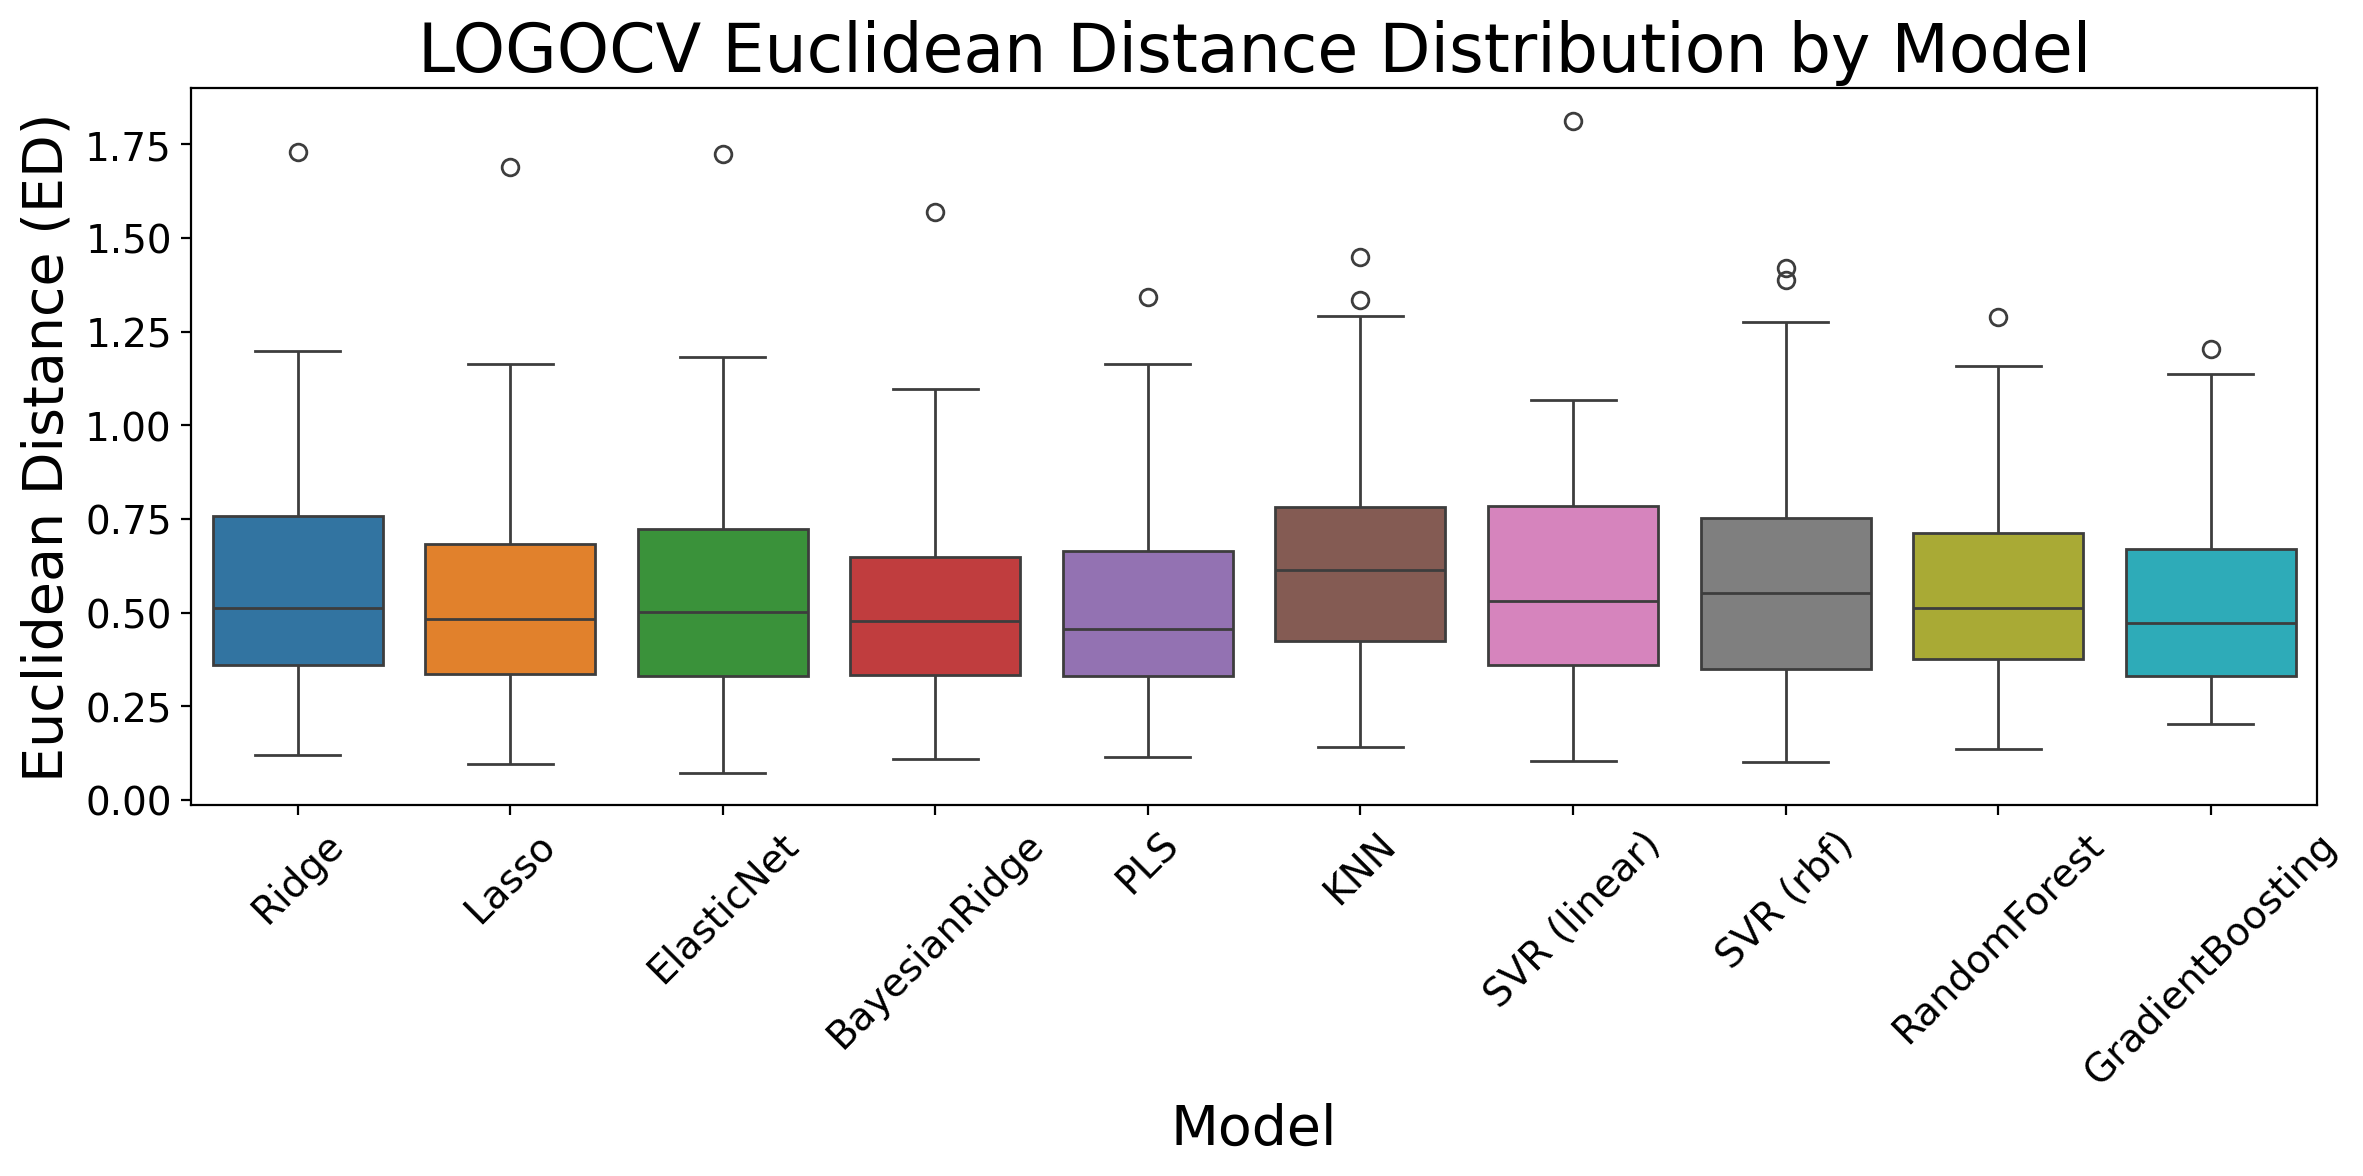

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# === Step 1: Per-model, per-subject ED extraction ===
model_ed_per_subject = {}

for result in detailed_results:
    model_name = result["Model"]
    config = model_configs[model_name]
    ed_all = [] # Initialize a single list to store EDs for the current model

    for train_idx, test_idx in logo.split(X, y, groups=groups):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        if config["scale"]:
            scaler = StandardScaler().fit(X_train)
            X_train = scaler.transform(X_train)
            X_test = scaler.transform(X_test)

        if config["pca"]:
            pca = PCA(n_components=var).fit(X_train)
            X_train = pca.transform(X_train)
            X_test = pca.transform(X_test)

        y_pred = []
        for i in range(3):
            model = config["model"]
            model.fit(X_train, y_train[:, i])
            y_pred.append(model.predict(X_test))

        y_pred = np.array(y_pred).T
        ed = np.linalg.norm(y_test - y_pred, axis=1) # This will produce [ED_R, ED_L] for the current subject
        current_groups = groups[test_idx]
        print(f"[CELL 2] Model: {model_name} | Group: {current_groups} | EDs: {np.round(ed, 4)}")
        ed_all.extend(ed) # Extend the list with [ED_R, ED_L] for each subject, interleaving them

    model_ed_per_subject[model_name] = ed_all # Store the interleaved EDs
    print(f"ED per subject for {model_name}: {ed_all}")

# === Step 2: Build summary table with median ± IQR ===
summary_rows = []
for model, eds in model_ed_per_subject.items():
    eds = np.array(eds)
    summary_rows.append({
        "Model": model,
        "Median ED": np.median(eds),
        "Q1 ED": np.percentile(eds, 25),
        "Q3 ED": np.percentile(eds, 75),
        "IQR": np.percentile(eds, 75) - np.percentile(eds, 25)
    })

df_summary = pd.DataFrame(summary_rows).sort_values(by="Median ED").reset_index(drop=True)
print("\n=== Summary: Median ± IQR (Euclidean Distance) ===")
print(df_summary.round(3))

# === Step 3: Boxplot of ED distribution by model ===
plt.figure(figsize=(12, 6))
ax = sns.boxplot(data=pd.DataFrame(model_ed_per_subject), showfliers=True)
plt.title("LOGOCV Euclidean Distance Distribution by Model", fontsize=24)
plt.ylabel("Euclidean Distance (ED)", fontsize=20)
plt.xlabel("Model", fontsize=20)

ax.tick_params(axis='both', labelsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:

# Get a sorted list of subject IDs (folders that start with "sub-")
SUBJIDs = sorted([name for name in os.listdir(dirafids) if name.startswith("sub-") and name not in drop_for_now])

# Create subject labels in the correct interleaved order (Sub-C001_R, Sub-C001_L, etc.)
ordered_subject_labels = []
for subjid in SUBJIDs:
    ordered_subject_labels.append(f"{subjid}_R")
    ordered_subject_labels.append(f"{subjid}_L")

print(SUBJIDs)
print(ordered_subject_labels)

['sub-C001', 'sub-C002', 'sub-C003', 'sub-C004', 'sub-C005', 'sub-C006', 'sub-C007', 'sub-C009', 'sub-C010', 'sub-C011', 'sub-C012', 'sub-C013', 'sub-C015', 'sub-C016', 'sub-C018', 'sub-C019', 'sub-C020', 'sub-C021', 'sub-C022', 'sub-C023', 'sub-C024', 'sub-C025', 'sub-C026', 'sub-C027', 'sub-C028', 'sub-C029', 'sub-C030', 'sub-C031', 'sub-C032', 'sub-C033', 'sub-C034']
['sub-C001_R', 'sub-C001_L', 'sub-C002_R', 'sub-C002_L', 'sub-C003_R', 'sub-C003_L', 'sub-C004_R', 'sub-C004_L', 'sub-C005_R', 'sub-C005_L', 'sub-C006_R', 'sub-C006_L', 'sub-C007_R', 'sub-C007_L', 'sub-C009_R', 'sub-C009_L', 'sub-C010_R', 'sub-C010_L', 'sub-C011_R', 'sub-C011_L', 'sub-C012_R', 'sub-C012_L', 'sub-C013_R', 'sub-C013_L', 'sub-C015_R', 'sub-C015_L', 'sub-C016_R', 'sub-C016_L', 'sub-C018_R', 'sub-C018_L', 'sub-C019_R', 'sub-C019_L', 'sub-C020_R', 'sub-C020_L', 'sub-C021_R', 'sub-C021_L', 'sub-C022_R', 'sub-C022_L', 'sub-C023_R', 'sub-C023_L', 'sub-C024_R', 'sub-C024_L', 'sub-C025_R', 'sub-C025_L', 'sub-C026_

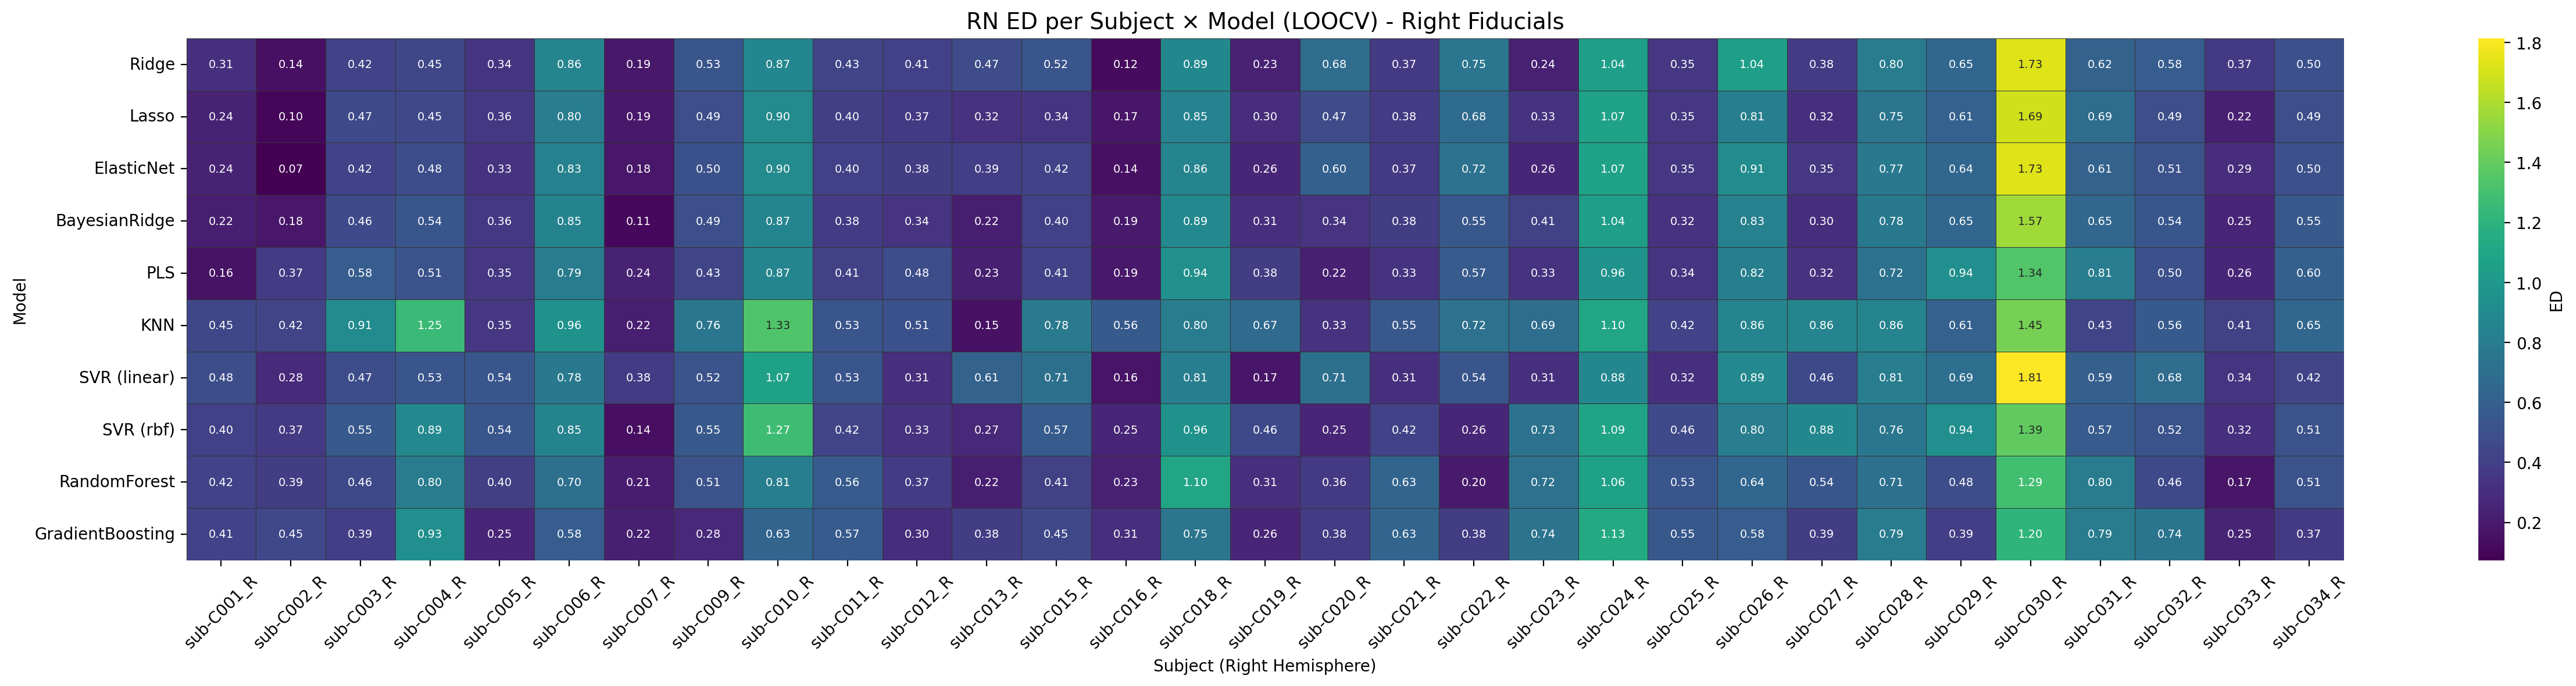

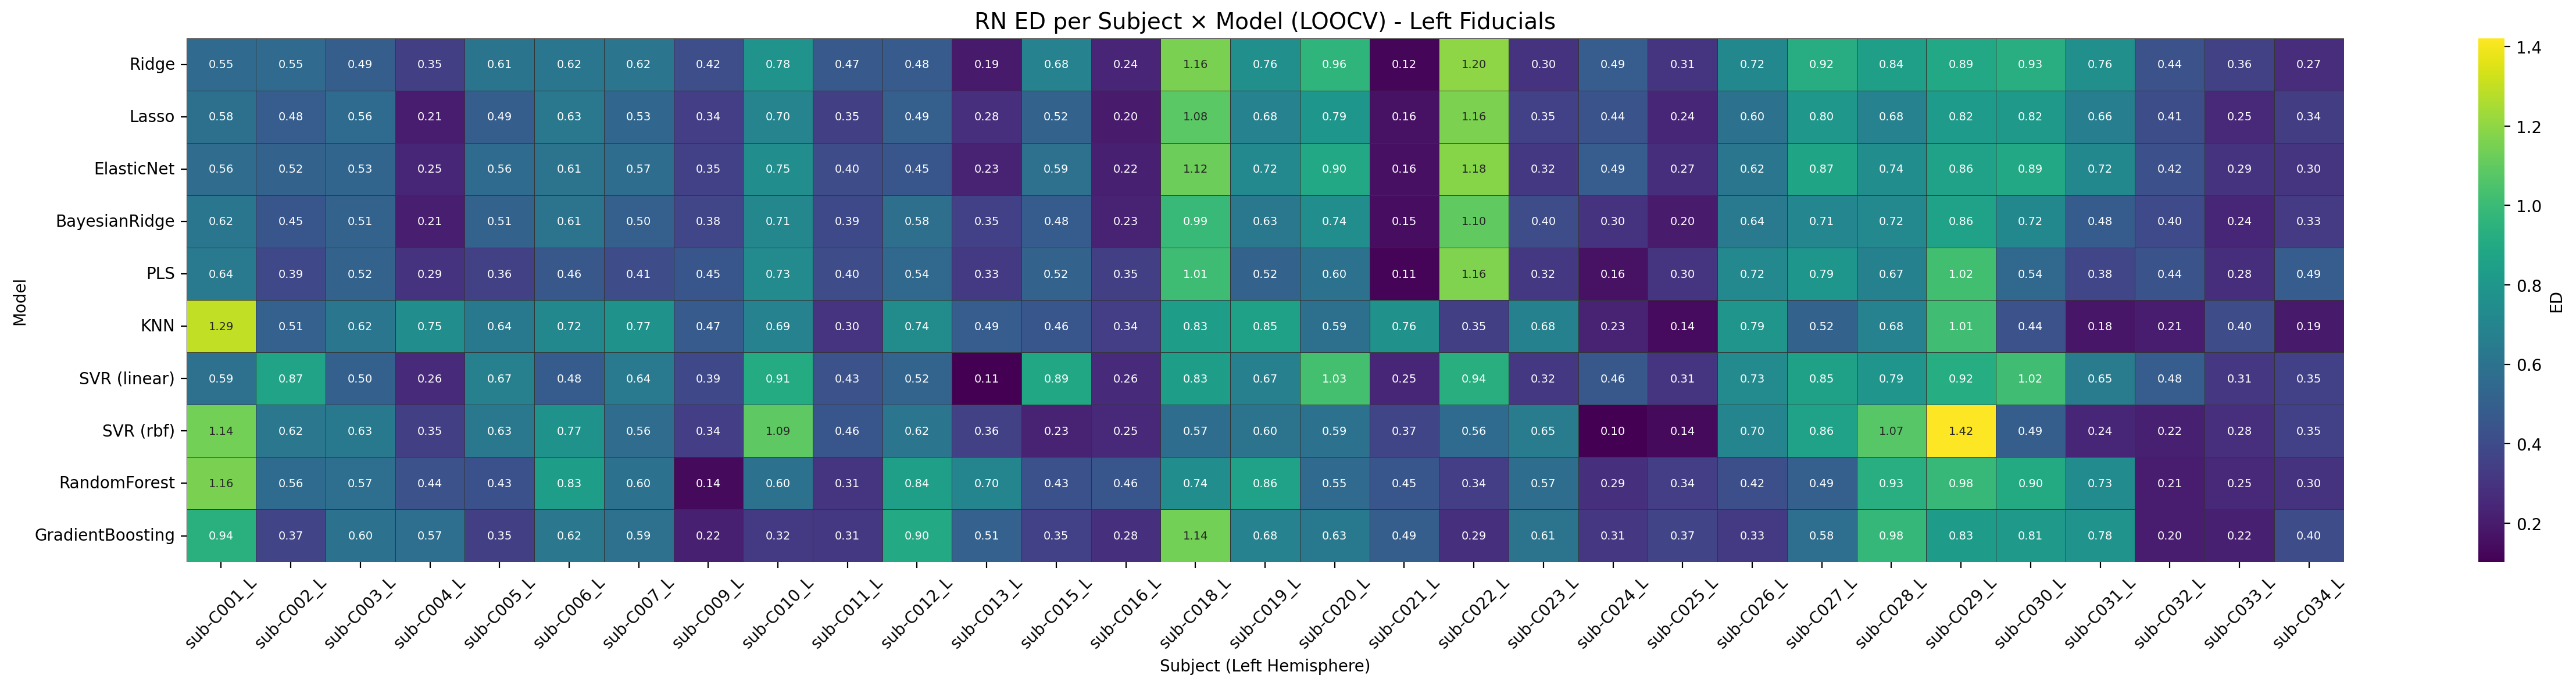

In [15]:
df_heatmap = pd.DataFrame(model_ed_per_subject).T  # Models x Subjects
# Assign the correctly ordered subject labels to the DataFrame columns
df_heatmap.columns = ordered_subject_labels

# Separate right and left hemisphere data using the correctly ordered labels
df_heatmap_right = df_heatmap[[col for col in df_heatmap.columns if '_R' in col]]
df_heatmap_left = df_heatmap[[col for col in df_heatmap.columns if '_L' in col]]

# Plot for Right Fiducials
plt.figure(figsize=(25, 6))
sns.heatmap(
    df_heatmap_right,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    cbar_kws={"label": "ED"},
    annot_kws={"size": 7},
    linewidths=0.3,
    linecolor="#333333"
)
plt.title("RN ED per Subject × Model (LOOCV) - Right Fiducials", fontsize=14)
plt.xlabel("Subject (Right Hemisphere)")
plt.ylabel("Model")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Plot for Left Fiducials
plt.figure(figsize=(25, 6))
sns.heatmap(
    df_heatmap_left,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    cbar_kws={"label": "ED"},
    annot_kws={"size": 7},
    linewidths=0.3,
    linecolor="#333333"
)
plt.title("RN ED per Subject × Model (LOOCV) - Left Fiducials", fontsize=14)
plt.xlabel("Subject (Left Hemisphere)")
plt.ylabel("Model")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [16]:
# -------- End of analysis relevant for CLAE Calgary

In [17]:
import numpy as np
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge, Lasso, ElasticNet, BayesianRidge
from sklearn.cross_decomposition import PLSRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

# === Parameters ===
var = 0.99            # PCA variance to retain
use_pca = True        # Toggle PCA
n_components = None   # Will be set by PCA automatically
logo = LeaveOneGroupOut()

# === Models (regressor per coordinate) ===
model_dict = {
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01, max_iter=5000),
    "ElasticNet": ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=5000),
    "BayesianRidge": BayesianRidge(),
    "PLS": PLSRegression(n_components=3),
    "KNN": KNeighborsRegressor(n_neighbors=3),
    "SVR (linear)": SVR(kernel='linear', C=1.0),
    "SVR (rbf)": SVR(kernel='rbf', C=1.0, gamma='scale'),
    "RandomForest": RandomForestRegressor(n_estimators=100, max_depth=5, random_state=0),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=0)
}

# === Track results
model_scores = {}

for model_name, base_model in model_dict.items():
    ed_all = []

    for train_idx, test_idx in logo.split(X, y, groups=groups):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # Preprocessing
        scaler = StandardScaler().fit(X_train)
        X_train_scaled = scaler.transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        if use_pca:
            pca = PCA(n_components=var).fit(X_train_scaled)
            X_train_scaled = pca.transform(X_train_scaled)
            X_test_scaled = pca.transform(X_test_scaled)

        # Train one model per coordinate
        y_pred = []
        for i in range(3):
            model = base_model
            model.fit(X_train_scaled, y_train[:, i])
            pred = model.predict(X_test_scaled)
            y_pred.append(pred)

        y_pred = np.array(y_pred).T
        ed = np.linalg.norm(y_test - y_pred)
        ed_all.append(ed)

    ed_all = np.array(ed_all)
    model_scores[model_name] = {
        'Mean ED': ed_all.mean(),
        'Std ED': ed_all.std()
    }

# === Report results
print("\n=== LOOCV Model Comparison ===")
for name, score in sorted(model_scores.items(), key=lambda x: x[1]['Mean ED']):
    print(f"{name:<18} | Mean ED: {score['Mean ED']:.2f} ± {score['Std ED']:.2f}")



=== LOOCV Model Comparison ===
BayesianRidge      | Mean ED: 0.76 ± 0.32
Lasso              | Mean ED: 0.77 ± 0.35
ElasticNet         | Mean ED: 0.80 ± 0.37
Ridge              | Mean ED: 0.84 ± 0.37
SVR (linear)       | Mean ED: 0.86 ± 0.35
SVR (rbf)          | Mean ED: 0.86 ± 0.36
PLS                | Mean ED: 0.87 ± 0.39
KNN                | Mean ED: 0.92 ± 0.30
RandomForest       | Mean ED: 0.95 ± 0.38
GradientBoosting   | Mean ED: 1.00 ± 0.34


In [18]:
df_detailed_results

,Model,MSE_x_mean,MSE_x_median,MSE_y_mean,MSE_y_median,MSE_z_mean,MSE_z_median,ED_mean,ED_median,ED_std
0,BayesianRidge,0.083583,0.041553,0.176643,0.064474,0.080219,0.039320,0.517826,0.478562,0.268887
1,PLS,0.083209,0.036715,0.163381,0.068838,0.092449,0.042000,0.520426,0.456319,0.261143
2,Lasso,0.085913,0.042999,0.190765,0.054754,0.082115,0.037962,0.527737,0.484529,0.283348
3,GradientBoosting,0.058316,0.022489,0.160704,0.068670,0.127264,0.061997,0.533149,0.473215,0.249071
4,ElasticNet,0.096091,0.050369,0.202398,0.044016,0.089163,0.052719,0.547510,0.500885,0.296453
5,RandomForest,0.083016,0.036782,0.184441,0.091115,0.107371,0.034774,0.554957,0.513752,0.258555
6,Ridge,0.113071,0.068296,0.211612,0.045339,0.098509,0.042566,0.576342,0.512731,0.301697
7,SVR (rbf),0.092969,0.031855,0.232749,0.073497,0.106636,0.042461,0.580788,0.552717,0.308285
8,SVR (linear),0.132695,0.084208,0.210335,0.062486,0.086168,0.038624,0.589118,0.531366,0.286598
9,KNN,0.092119,0.036332,0.257607,0.148673,0.125052,0.035826,0.624758,0.613897,0.290610


In [19]:
import os
import pickle
import numpy as np

from sklearn.base import clone
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.decomposition import PCA

# ============================================================
# SELECT BEST MODEL
# ============================================================

best_model_name = df_detailed_results.iloc[0]["Model"]
best_model_config = model_configs[best_model_name]

print(f"Best model: {best_model_name}")
print(f"Uses scaling: {best_model_config['scale']}")
print(f"Uses PCA: {best_model_config['pca']}")


# ============================================================
# FULL TRAINING DATA
# ============================================================

X_full = df_afids_proc_train
y_full = df_RN_proc_train

if X_full.shape[0] != y_full.shape[0]:
    raise ValueError(
        f"X/y row mismatch: X={X_full.shape}, y={y_full.shape}"
    )

if y_full.ndim != 2 or y_full.shape[1] != 3:
    raise ValueError(
        f"Expected y shape (n_samples, 3), got {y_full.shape}"
    )


# ============================================================
# PREPROCESSING
#
# The inference script always calls:
#
#     standard_scaler.transform(...)
#     pca.transform(...)
#
# Therefore, when a model does not require one of these stages,
# we save an identity transformer so the inference code can
# remain unchanged.
# ============================================================

if best_model_config["scale"]:
    scaler = StandardScaler()
    X_processed = scaler.fit_transform(X_full)
else:
    scaler = FunctionTransformer(validate=False)
    X_processed = scaler.fit_transform(X_full)


if best_model_config["pca"]:
    pca = PCA(n_components=var)
    X_processed = pca.fit_transform(X_processed)

    print(
        f"PCA retained variance: "
        f"{pca.explained_variance_ratio_.sum():.5f}"
    )
    print(f"PCA components: {X_processed.shape[1]}")
else:
    pca = FunctionTransformer(validate=False)
    X_processed = pca.fit_transform(X_processed)


# ============================================================
# TRAIN AN INDEPENDENT MODEL FOR X, Y, AND Z
# ============================================================

models_for_coords = {}

for i, coord in enumerate(["x", "y", "z"]):

    # CRITICAL:
    # clone() creates a NEW, unfitted estimator with the same
    # hyperparameters as the selected best model.
    model = clone(best_model_config["model"])

    model.fit(
        X_processed,
        y_full[:, i]
    )

    models_for_coords[coord] = model

    print(
        f"Trained {coord}-coordinate model "
        f"using target column {i}"
    )


# ============================================================
# VERIFY THEY ARE ACTUALLY THREE DIFFERENT OBJECTS
# ============================================================

print("\n=== MODEL OBJECT CHECK ===")

print(
    "x is y:",
    models_for_coords["x"] is models_for_coords["y"]
)

print(
    "x is z:",
    models_for_coords["x"] is models_for_coords["z"]
)

print(
    "y is z:",
    models_for_coords["y"] is models_for_coords["z"]
)


assert models_for_coords["x"] is not models_for_coords["y"]
assert models_for_coords["x"] is not models_for_coords["z"]
assert models_for_coords["y"] is not models_for_coords["z"]


# ============================================================
# VERIFY PREDICTIONS BEFORE SAVING
# ============================================================

pred_x = np.asarray(
    models_for_coords["x"].predict(X_processed)
).squeeze()

pred_y = np.asarray(
    models_for_coords["y"].predict(X_processed)
).squeeze()

pred_z = np.asarray(
    models_for_coords["z"].predict(X_processed)
).squeeze()


training_predictions = np.column_stack([
    pred_x,
    pred_y,
    pred_z
])


print("\n=== SAMPLE PREDICTIONS ===")

print("Predicted:")
print(training_predictions[:5])

print("\nGround truth:")
print(y_full[:5])


print("\n=== IDENTICAL-PREDICTION CHECK ===")

print(
    "x == y:",
    np.allclose(pred_x, pred_y)
)

print(
    "x == z:",
    np.allclose(pred_x, pred_z)
)

print(
    "y == z:",
    np.allclose(pred_y, pred_z)
)


if (
    np.allclose(pred_x, pred_y)
    and np.allclose(pred_x, pred_z)
):
    raise RuntimeError(
        "ERROR: x, y, and z models are producing identical "
        "predictions. Do not save this model."
    )


# ============================================================
# BUILD FINAL MODEL DICTIONARY
# ============================================================

final_model_dict = {
    "standard_scaler": scaler,
    "pca": pca,
    "x": models_for_coords["x"],
    "y": models_for_coords["y"],
    "z": models_for_coords["z"],
}


# ============================================================
# SAVE
# ============================================================

model_output_dir = "/content/final_model/"
os.makedirs(
    model_output_dir,
    exist_ok=True
)

safe_model_name = (
    best_model_name
    .lower()
    .replace(" ", "_")
    .replace("(", "")
    .replace(")", "")
)

model_filename = (
    f"{safe_model_name}_RN_prediction_model.pkl"
)

full_model_path = os.path.join(
    model_output_dir,
    model_filename
)


with open(full_model_path, "wb") as file:
    pickle.dump(
        final_model_dict,
        file,
        protocol=pickle.HIGHEST_PROTOCOL
    )


print(
    f"\nBest performing model ({best_model_name}) "
    f"saved successfully to:\n{full_model_path}"
)


# ============================================================
# RELOAD THE PICKLE AND VERIFY IT
# ============================================================

with open(full_model_path, "rb") as file:
    loaded_model = pickle.load(file)


print("\n=== SAVED PICKLE OBJECT CHECK ===")

print(
    "x is y:",
    loaded_model["x"] is loaded_model["y"]
)

print(
    "x is z:",
    loaded_model["x"] is loaded_model["z"]
)

print(
    "y is z:",
    loaded_model["y"] is loaded_model["z"]
)


# Run saved preprocessing
X_verify = loaded_model["standard_scaler"].transform(
    X_full
)

X_verify = loaded_model["pca"].transform(
    X_verify
)


# Run saved models
verify_x = np.asarray(
    loaded_model["x"].predict(X_verify)
).squeeze()

verify_y = np.asarray(
    loaded_model["y"].predict(X_verify)
).squeeze()

verify_z = np.asarray(
    loaded_model["z"].predict(X_verify)
).squeeze()


print("\n=== SAVED PICKLE PREDICTION CHECK ===")

print(
    "x == y:",
    np.allclose(verify_x, verify_y)
)

print(
    "x == z:",
    np.allclose(verify_x, verify_z)
)

print(
    "y == z:",
    np.allclose(verify_y, verify_z)
)


print("\nFirst 5 saved-model predictions:")

print(
    np.column_stack([
        verify_x,
        verify_y,
        verify_z
    ])[:5]
)


if (
    np.allclose(verify_x, verify_y)
    and np.allclose(verify_x, verify_z)
):
    raise RuntimeError(
        "ERROR: Saved model produces identical x/y/z "
        "predictions."
    )

print("\nSaved model verification PASSED.")

Best model: BayesianRidge
Uses scaling: True
Uses PCA: True
PCA retained variance: 0.99266
PCA components: 22
Trained x-coordinate model using target column 0
Trained y-coordinate model using target column 1
Trained z-coordinate model using target column 2

=== MODEL OBJECT CHECK ===
x is y: False
x is z: False
y is z: False

=== SAMPLE PREDICTIONS ===
Predicted:
[[ 4.89860699 -7.787107   -5.50897547]
 [ 4.24314545 -7.25411286 -5.21974565]
 [ 4.25680507 -6.83477153 -4.96270067]
 [ 5.02313829 -7.64247553 -4.61960139]
 [ 5.02190713 -7.49153399 -5.2134187 ]]

Ground truth:
[[ 5.0057  -7.76179 -5.49243]
 [ 4.27025 -7.08814 -5.19719]
 [ 4.33184 -6.65974 -4.77737]
 [ 5.17047 -7.46202 -4.3178 ]
 [ 5.23392 -7.39267 -5.13601]]

=== IDENTICAL-PREDICTION CHECK ===
x == y: False
x == z: False
y == z: False

Best performing model (BayesianRidge) saved successfully to:
/content/final_model/bayesianridge_RN_prediction_model.pkl

=== SAVED PICKLE OBJECT CHECK ===
x is y: False
x is z: False
y is z: Fa